In [29]:
"""
Case Study :Self-Pruning Neural Network
Implements:
- Custom PrunableLinear layer (NO torch.nn.Linear)
- L1 sparsity regularization on gates
- Training on CIFAR-10
- Sparsity + accuracy evaluation

Author: Meghavi Sisodiya (ME-AI)
"""

%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [30]:
# 1. PRUNABLE LINEAR LAYER
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

In [31]:
# 2. MODEL DEFINITION
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [32]:
# 3. SPARSITY LOSS (L1 ON GATES)
def compute_sparsity_loss(model):
    loss = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    return 100 * pruned / total

In [33]:
# 4. DATA LOADING (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [19]:
# 5. EVALUATION FUNCTION
def train_model(lambda_, epochs=5):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            classification_loss = F.cross_entropy(outputs, labels)

            sparsity_loss = compute_sparsity_loss(model)

            loss = classification_loss + lambda_ * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        acc = evaluate(model, testloader)
        print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Acc: {acc:.2f}%")

    final_acc = evaluate(model, testloader)
    sparsity = calculate_sparsity(model)

    return model, final_acc, sparsity

In [9]:
# 6. SPARSITY CALCULATION
def calculate_sparsity(model, threshold=1e-2):
    """
    Calculates percentage of pruned weights (gates near zero).
    """
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    return 100 * pruned / total

In [10]:
# 7. TRAINING FUNCTION
def train_model(lambda_, trainloader, testloader, epochs=5):
    """
    Trains model with given lambda (sparsity strength).
    """
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            # Classification loss
            classification_loss = F.cross_entropy(outputs, labels)

            # Sparsity loss
            sparsity_loss = compute_sparsity_loss(model)

            # Total loss
            loss = classification_loss + lambda_ * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc = evaluate(model, testloader)
        print(f"Lambda {lambda_} | Epoch {epoch+1} | Loss {running_loss:.2f} | Acc {acc:.2f}%")

    final_acc = evaluate(model, testloader)
    sparsity = calculate_sparsity(model)

    return model, final_acc, sparsity

In [22]:
model, acc, sparsity = train_model(0.01)

print("\nFinal Accuracy:", acc)
print("Sparsity:", sparsity)

Epoch 1 | Loss: 3070020.89 | Acc: 44.93%
Epoch 2 | Loss: 2547117.54 | Acc: 48.81%
Epoch 3 | Loss: 2064797.72 | Acc: 51.34%
Epoch 4 | Loss: 1644094.43 | Acc: 52.78%
Epoch 5 | Loss: 1295840.54 | Acc: 52.77%

Final Accuracy: 52.77
Sparsity: 0.07940247149714971


Total gates: 1706496


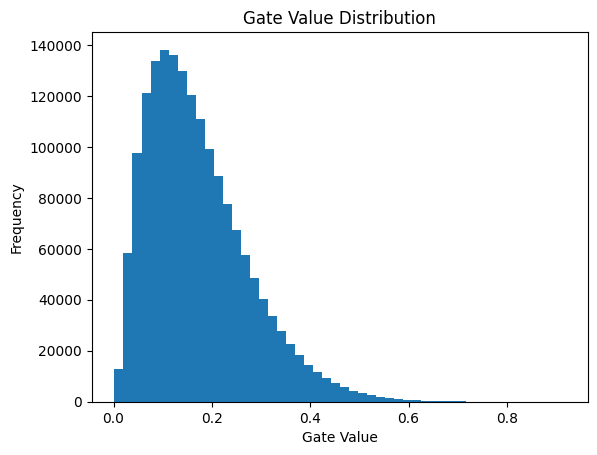

In [23]:
# PLOT GRAPH
def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    print("Total gates:", len(all_gates))  # debug

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()


plot_gate_distribution(model)

In [24]:
#Running multiple values
lambdas = [0.001, 0.01, 0.1]

results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model, acc, sparsity = train_model(lam)

    results.append((lam, acc, sparsity))


Training with lambda = 0.001
Epoch 1 | Loss: 307560.19 | Acc: 46.31%
Epoch 2 | Loss: 255208.00 | Acc: 48.86%
Epoch 3 | Loss: 206966.85 | Acc: 51.30%
Epoch 4 | Loss: 164908.56 | Acc: 52.92%
Epoch 5 | Loss: 130105.41 | Acc: 54.04%

Training with lambda = 0.01
Epoch 1 | Loss: 3069711.48 | Acc: 45.13%
Epoch 2 | Loss: 2546765.46 | Acc: 49.45%
Epoch 3 | Loss: 2064451.86 | Acc: 51.38%
Epoch 4 | Loss: 1643792.44 | Acc: 52.77%
Epoch 5 | Loss: 1295599.58 | Acc: 53.03%

Training with lambda = 0.1
Epoch 1 | Loss: 30687909.06 | Acc: 45.90%
Epoch 2 | Loss: 25460799.00 | Acc: 49.02%
Epoch 3 | Loss: 20639314.43 | Acc: 51.04%
Epoch 4 | Loss: 16433590.61 | Acc: 51.64%
Epoch 5 | Loss: 12951790.19 | Acc: 52.89%


In [25]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity (%)")

for lam, acc, sp in results:
    print(f"{lam} | {acc:.2f}% | {sp:.2f}%")


Final Results:
Lambda | Accuracy | Sparsity (%)
0.001 | 54.04% | 0.07%
0.01 | 53.03% | 0.08%
0.1 | 52.89% | 0.08%


Total gates: 1706496


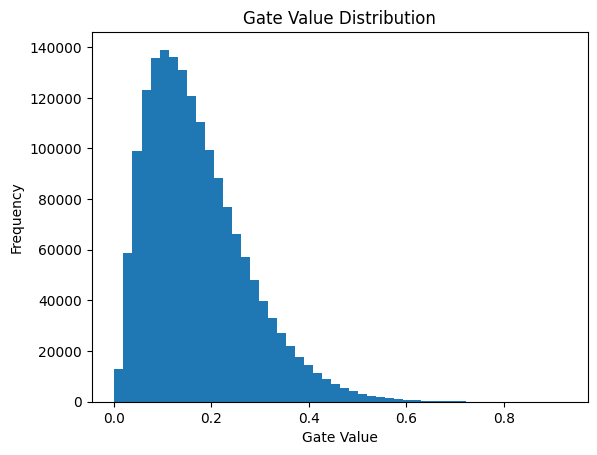

In [26]:
#Plotting the best model graph
plot_gate_distribution(model)